<div align="center">
  <img src="title.png" width="1200">
</div>

<div style="font-size: 125%; line-height: 1.6;">

# Quantum Variational Circuits: 2-Pixel Line Detection

In this workshop, we will tackle a fundamental computer vision problem using a Variational Quantum Classifier (VQC). 

By the end of this workshop you should be able to:

* Load data from a 2D image into a 1D quantum circuit
* Construct an ansatz for a VQC, and adjust its entanglement to fit your specific problem
* Train your VQC and use it to make accurate predictions on test data
* Execute your model on real IBM Quantum hardware

We will train our quantum model to differentiate between two types of features on a $2 \times 4$ pixel grid:
* **Horizontal Lines:** A row of 2 illuminated pixels.
* **Vertical Lines:** A column of 2 illuminated pixels.

Crucially, both shapes contain exactly the same amount of "light" (2 pixels), and they can appear anywhere on the grid. The quantum computer cannot simply memorize pixel locations or measure total brightness; it must learn the spatial correlation of the shapes themselves using **Nearest-Neighbor Entanglement**.

### The QML Workflow: From Circuit to Result
1. **Data Encoding & Circuit Design:** Map classical datasets into quantum feature maps and construct the 2D "Quantum Convolution" or parameterized circuit architecture.
2. **Hardware Tailoring:** Transpile and compile the abstract circuit to match the specific connectivity, gate set, and noise profile of the target quantum processor.
3. **Training & Inference:** Use Qiskit Runtime Primitives to execute iterative training loops and perform final model inference for prediction generation.
4. **Analysis & Evaluation:** Post-process the output data to visualize loss curves and calculate final classification accuracy to determine model performance.
</div>

<div align="center">
  <img src="qml_workflow.png" width="800">
</div>

## Data generation

#### We define a dataset where 2-pixel lines can appear in any valid position on the $2 \times 4$ grid. We also add background noise to make the classification a true machine learning challenge.

In [306]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Total number of "pixels"/qubits
size = 8
# Image dimensions: 2 rows x 4 columns
vert_size = 2
hor_size = round(size / vert_size)
# Length of the lines to detect
line_size = 2

def generate_dataset(num_images):
    images = []
    labels = []
    
    # Pre-calculate all possible horizontal and vertical patterns
    hor_array = np.zeros((size - (line_size - 1) * vert_size, size))
    ver_array = np.zeros((round(size / vert_size) * (vert_size - line_size + 1), size))

    j = 0
    for i in range(0, size - 1):
        if i % (size / vert_size) <= (size / vert_size) - line_size:
            for p in range(0, line_size):
                hor_array[j][i + p] = np.pi / 2
            j += 1

    j = 0
    for i in range(0, round(size / vert_size) * (vert_size - line_size + 1)):
        for p in range(0, line_size):
            ver_array[j][i + p * round(size / vert_size)] = np.pi / 2
        j += 1

    for n in range(num_images):
        rng = np.random.randint(0, 2)
        if rng == 0:
            labels.append(-1) # Horizontal
            random_image = np.random.randint(0, len(hor_array))
            images.append(np.array(hor_array[random_image]))
        elif rng == 1:
            labels.append(1) # Vertical
            random_image = np.random.randint(0, len(ver_array))
            images.append(np.array(ver_array[random_image]))

        # Add Noise
        for i in range(size):
            if images[-1][i] == 0:
                images[-1][i] = np.random.rand() * np.pi / 4
                
    return np.array(images), labels

# Generate and split data
np.random.seed(42)
images, labels = generate_dataset(200)
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.3, random_state=246
)

#### Plot the image

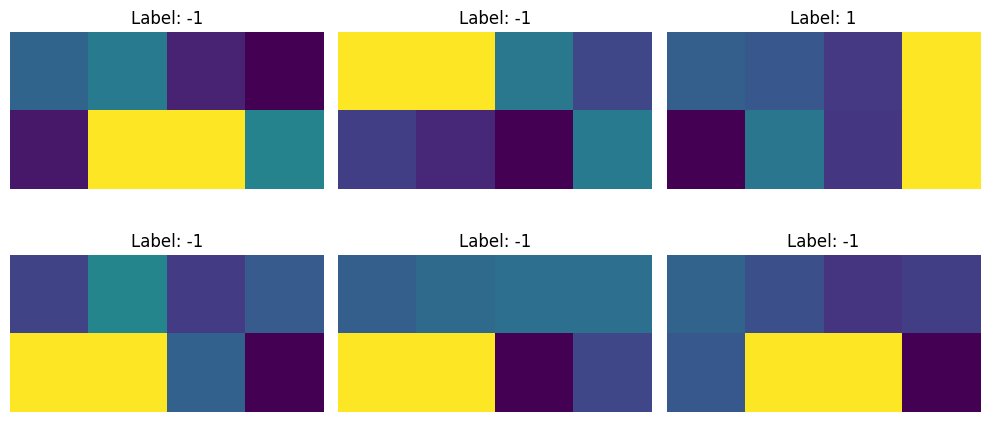

In [307]:
fig, ax = plt.subplots(2, 3, figsize=(10, 5))
for i in range(6):
    idx = np.random.randint(len(train_images))
    ax[i//3, i%3].imshow(train_images[idx].reshape(vert_size, hor_size), cmap='viridis')
    ax[i//3, i%3].set_title(f"Label: {train_labels[idx]}")
    ax[i//3, i%3].axis('off')
plt.tight_layout()
plt.show()

## 1. **Data Encoding & Circuit Design:**

#### To bridge the gap between classical data and quantum computation, we define a function $f_{\theta}(\vec{x})$ that processes an input vector $\vec{x}$ (like image pixels) to produce a classification label. This is the heart of a Variational Quantum Circuit (VQC).

<div align="center">
  <img src="qml_formula.png" width="600">
</div>


#### Think of this process as a three-stage quantum pipeline:

**The Feature Map $U(\vec{x})$:** This "loads" your classical data into quantum states. By applying data-dependent rotations, we move from a simple $|0\rangle$ state into a complex high-dimensional Hilbert space where patterns might be easier to separate.

**The Ansatz $W(\theta)$:** This is the "brain" of your circuit. It consists of tunable quantum gates (parameters $\theta$) that we adjust—much like weights in a classical neural network—to find the optimal transformation for our specific task.

**The Observable $O$:** Finally, we perform a measurement. By calculating the expectation value of an operator $O$, we collapse the quantum information back into a classical number that tells us whether the result is a $+1$ or a $-1$.

### Conjugate Matrices = Quantum CTRL+Z 😎

In 

$$
f_\theta(\vec{x}) = \langle 0 | U^\dagger(\vec{x}) \, W^\dagger(\theta) \, O \, W(\theta) \, U(\vec{x}) | 0 \rangle
$$

the † (dagger) is like hitting **CTRL+Z** in your quantum circuit:

- **U†(x)**: rewinds your data back to |0⟩  
- **W†(θ)**: un-does the brain’s work  

💡 Purpose: this lets **O measure the effect of your circuit** cleanly without messing up the original state.  

Think: blend → measure → unblend. Quantum smoothie! 🍹  

ℹ️ You can find more info about conjugate and unitary matrices [in this course](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/multiple-systems/quantum-information#unitary-operations).

#### Now, we need to address a fundamental challenge:  
#### A quantum computer cannot "see" classical data. It doesn't understand pixels, spreadsheets, or raw numbers in their native format. To a quantum processor, your image is just a collection of classical bits, but it needs to work with quantum states.

#### This is where **Data Encoding** steps in. It acts as the translator that "uploads" your classical vector $\vec{x}$ into the vast, high-dimensional Hilbert space of the qubits.

#### In this workshop, we use the [**Z Feature Map**](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding#z-feature-map) to perform this translation. Each feature in your input vector is encoded as a rotation on a qubit around the Z-axis, so the number of qubits determines how many features we can encode at once. For our dataset, one qubit per feature is sufficient, which keeps the circuit simple and efficient while capturing all the information we need for learning.

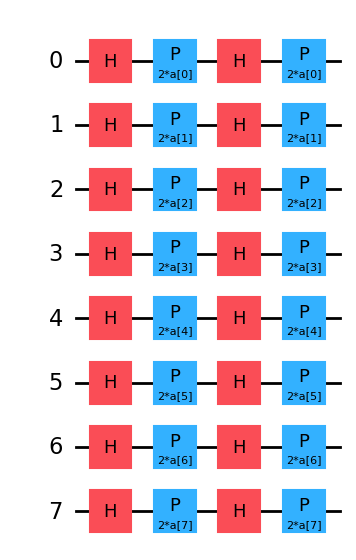

In [308]:
from qiskit.circuit.library import z_feature_map

# One qubit per data feature
num_qubits = len(train_images[0])

# Data encoding
# Note that qiskit orders parameters alphabetically. We assign the parameter prefix "a" to ensure our data encoding goes to the first part of the circuit, the feature mapping.
feature_map = z_feature_map(num_qubits, parameter_prefix="a")
feature_map.draw(output='mpl')

## Choosing an Ansatz ⚛

Now that our data is encoded into a quantum state, we need a way to **process and learn from it**.

This is where the **Ansatz** comes in.

The Ansatz is a parameterized quantum circuit with tunable parameters $\theta$ (like weights in a neural network).

In this workshop, we use:

- **Rotation gates (RY, RX)** — they "rotate" the qubit state, changing its value in a controllable way (this is how we introduce learnable parameters). For now, you can think of this step simply as an operation that adjusts the qubit based on $\theta$.  
- **CNOT gates** — they connect qubits together, allowing them to share information. For now, think of this as an operation that lets qubits influence each other.
- 
Together, these let the circuit learn patterns in the data.

---

💡 When choosing an ansatz:

- keep it **simple** (hardware is noisy)  
  Quantum computers are error-prone, so deeper circuits (especially with many two-qubit gates) can quickly degrade results. Simpler circuits are usually more reliable.

- match the **problem structure**  
  Try to design the circuit in a way that reflects your data. For example, for images, it makes sense to connect **neighboring qubits**, since nearby pixels are often related.

- avoid too many **parameters**  
  More parameters give more flexibility, but also make training slower and harder. A smaller, well-structured ansatz is often easier to optimize.

Let’s build it 👇

5
2+ qubit depth: 3


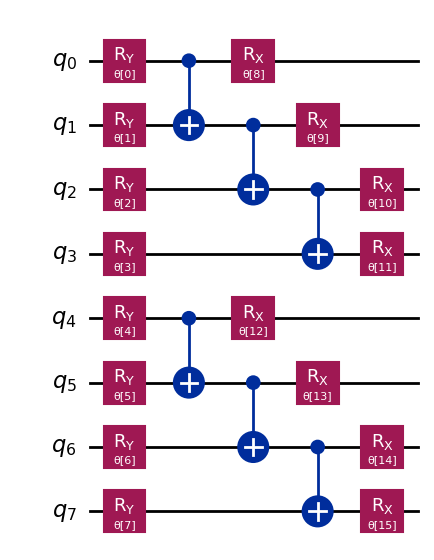

In [309]:
# Import the necessary packages
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(size)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * size)

# A first variational layer:
for i in range(size):
    qnn_circuit.ry(params[i], i)

# Here is a list of qubit pairs between which we want CNOT gates. The choice of these is not yet obvious.
# Extended list of qubit pairs covering both top and bottom horizontal lines
qnn_cnot_list = [[0, 1], [1, 2], [2, 3], [4, 5], [5, 6], [6, 7]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(size):
    qnn_circuit.rx(params[size + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Draw the circuit
qnn_circuit.draw("mpl")

## Building the Full Quantum Model

Now we combine everything together.

We take:
- the **feature map $U(\vec{x})$** (data encoding)  
- the **ansatz $W(\theta)$** (trainable circuit)  

and stack them into a single quantum circuit.

This is very similar to a neural network:
- input layer → $U(\vec{x})$  
- trainable layers → $W(\theta)$  

Together, they form our **Quantum Neural Network (QNN)**.

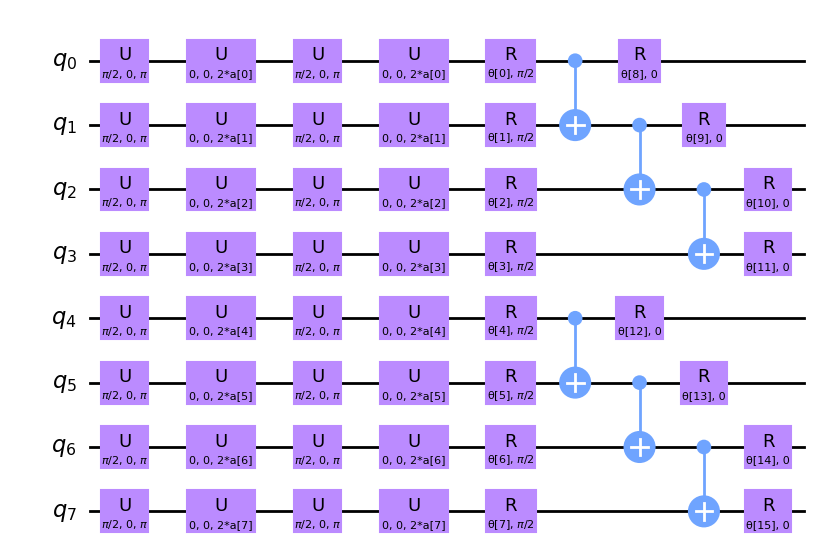

In [310]:
# QNN ansatz
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

## 🎉 Congratulations!

You’ve just built your **Variational Quantum Circuit (VQC)**!  

But don’t think that’s the end — this is only the **model structure**. Next, we need to prepare the code to **train the VQC and make it learn from our data**, so it can actually start solving the task.

### Defining the Observable 🧭

Next, we define an **observable**, which is an operator we can measure on the quantum circuit to get a classical number. Here, we use a `Z` operator on each qubit. Technically, this means we are measuring in the [Pauli Z basis]('https://quantum.cloud.ibm.com/learning/en/courses/foundations-of-quantum-error-correction/stabilizer-formalism/pauli-operations-and-observables'), which gives eigenvalues of +1 or -1. For our binary classification task, each qubit carries information about the input, and measuring all of them produces a value we can feed into the cost function to guide training.

In [311]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_list([("Z" * (num_qubits), 1)])

Before we can train our quantum neural network, we need a way to get outputs from the circuit. That’s what the **forward pass** does.  

The function takes `input_params` and `weight_params` separately. The `input_params` represent the data we want to encode, like image pixels, and the `weight_params` are the tunable parameters of the ansatz that will be optimized.  

In [312]:
from qiskit.primitives import BaseEstimatorV2
from qiskit.quantum_info.operators.base_operator import BaseOperator


def forward(
    circuit: QuantumCircuit,
    input_params: np.ndarray,
    weight_params: np.ndarray,
    estimator: BaseEstimatorV2,
    observable: BaseOperator,
) -> np.ndarray:
    """
    Forward pass of the neural network.

    Args:
        circuit: circuit consisting of data loader gates and the neural network ansatz.
        input_params: data encoding parameters.
        weight_params: neural network ansatz parameters.
        estimator: EstimatorV2 primitive.
        observable: a single observable to compute the expectation over.

    Returns:
        expectation_values: an array (for one observable) or a matrix (for a sequence of observables) of expectation values.
        Rows correspond to observables and columns to data samples.
    """
    num_samples = input_params.shape[0]
    weights = np.broadcast_to(weight_params, (num_samples, len(weight_params)))
    params = np.concatenate((input_params, weights), axis=1)
    pub = (circuit, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    expectation_values = result.data.evs

    return expectation_values

### How does our QNN learn? 🤔

Now we bring in classical methods. To train our model, we need a **loss function** that tells us how well the QNN is performing.

The loss function compares the predicted labels from our model with the true labels and measures the difference between them. In our case, we use **Mean Squared Error (MSE)**, which simply computes the average of the squared differences.

There are many possible loss functions, but MSE is a simple and effective choice for our example.

In [313]:
def mse_loss(predict: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Mean squared error (MSE).

    prediction: predictions from the forward pass of neural network.
    target: true labels.

    output: MSE loss.
    """
    if len(predict.shape) <= 1:
        return ((predict - target) ** 2).mean()
    else:
        raise AssertionError("input should be 1d-array")

Now we define a slightly different version of the loss function that depends only on the **trainable parameters** (weights). This is the function the classical optimizer will use during training.

Instead of passing all inputs every time, we fix the data and other components, and only vary the `weight_params`. For each set of weights, the function runs a forward pass, computes the loss, and returns a single value representing how well the model is performing.

The optimizer will repeatedly call this function, trying different values of the weights and gradually minimizing the loss.

In [314]:
def mse_loss_weights(weight_params: np.ndarray) -> np.ndarray:
    """
    Cost function for the optimizer to update the ansatz parameters.

    weight_params: ansatz parameters to be updated by the optimizer.

    output: MSE loss.
    """
    predictions = forward(
        circuit=circuit,
        input_params=input_params,
        weight_params=weight_params,
        estimator=estimator,
        observable=observable,
    )

    cost = mse_loss(predict=predictions, target=target)
    objective_func_vals.append(cost)

    global iter
    if iter % 50 == 0:
        print(f"Iter: {iter}, loss: {cost}")
    iter += 1

    return cost

---

## Qiskit Patterns Step 2: Optimize problem for quantum execution

We start by selecting a backend for execution. In this case, we will use the least-busy backend.



Now it’s your turn to try this on a **real quantum computer** 🚀

To do that, you’ll need an **IBM Quantum API key**:
- Go to the IBM Quantum portal  
- Create an account (if you don’t have one)  
- Copy your API key and connect it in your environment  

💡 You get **free access to real quantum hardware (10 minutes)**, which is perfect for testing your circuits.

## 🔐 Setting Up Your IBM Quantum API Key

After creating your API key, we need to **store it securely** and connect to IBM Quantum.

Store your API key as an environment variable using a `.env` file.

Start by copying the template file:

In [315]:
!cp .env.example .env

Then open .env and paste your API key:
IBM_QUANTUM_API_KEY=your_api_key_here

In [316]:
import os
from dotenv import load_dotenv
from qiskit_ibm_runtime import QiskitRuntimeService

# Load variables from .env file
load_dotenv()
api_key = os.getenv("IBM_QUANTUM_API_KEY")

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=api_key,
    overwrite=True
)

We will set some initial global variables for the cost function.

In [317]:
# Globals
circuit = full_circuit
observables = observable
# input_params = train_images_batch
# target = train_labels_batch
objective_func_vals = []
iter = 0

Now we need to select a **real quantum backend** to run our QNN.  

In this workshop, we’ll use the **least busy backend**, so our jobs can be executed faster with minimal waiting time.

In [318]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-03-23 14:45:27,794: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-23 14:45:28,269: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-23 14:45:31,162: Using instance: open-instance, plan: open


ibm_fez


## Optimizing the Circuit for Real Hardware ⚙️

Before running on a real quantum computer, we need to **adapt (transpile) our circuit** to match the hardware.

Real devices have constraints:
- specific qubit connections  
- limited gate sets  
- noise and decoherence  

In the code below, we:
- set a high **optimization level (3)** to simplify and improve the circuit  
- apply **scheduling** to organize when gates are executed  
- add **dynamical decoupling**, which inserts extra gates to help protect qubits from noise  

Don’t worry if this part feels a bit advanced - that’s totally normal. These are lower-level optimizations that you’ll understand better with more experience. For now, just think of this step as **preparing your circuit to run reliably on real hardware**.

In [293]:
# Import required tools for circuit optimization and scheduling
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Get hardware-specific information (gate set, connectivity, timing constraints)
target = backend.target

# Generate a preset pass manager with a high optimization level
# This will simplify the circuit and adapt it to the hardware
pm = generate_preset_pass_manager(target=target, optimization_level=3)

# Add a custom scheduling step to further optimize execution timing
pm.scheduling = PassManager(
    [
        # Schedule operations as late as possible (reduces idle time at the end)
        ALAPScheduleAnalysis(target=target),

        # Adjust timing to satisfy hardware alignment constraints
        ConstrainedReschedule(
            acquire_alignment=target.acquire_alignment,
            pulse_alignment=target.pulse_alignment,
            target=target,
        ),

        # Insert extra X gates during idle periods to reduce noise (dynamical decoupling)
        PadDynamicalDecoupling(
            target=target,
            dd_sequence=[XGate(), XGate()],  # simple XX sequence
            pulse_alignment=target.pulse_alignment,
        ),
    ]
)

## Applying the Pass Manager 🏁

Now we apply the **pass manager** to our full circuit. This adjusts the circuit layout and optimizes it for the target backend.

It’s important to also apply the same layout changes to the **observable**, so measurements match the new qubit arrangement.

For very large circuits, the heuristics used during optimization may not always produce the shallowest or most efficient circuit. In those cases, running the pass manager multiple times and selecting the best result can help — something we’ll explore when we scale up.


In [294]:
# Apply the pass manager to optimize the full circuit
circuit_ibm = pm.run(full_circuit)

# Apply the resulting layout to the observable as well
observable_ibm = observable.apply_layout(circuit_ibm.layout)

## Qiskit Patterns Step 3: Execute using Qiskit Primitives

### Looping Over the Dataset: Batches and Epochs 🌀

Now we’re ready to **train our quantum neural network**. We go through the dataset in small batches and repeat this process over a number of epochs.  

For each batch, we select a subset of images and their labels. The images are encoded into the circuit as `input_params`, and the labels become the `target`. Then, a classical optimizer (COBYLA) updates the ansatz parameters (`weight_params`) by minimizing the loss function.  

In [295]:
from qiskit.primitives import StatevectorEstimator as Estimator
from scipy.optimize import minimize

batch_size = 140
num_epochs = 1
num_samples = len(train_images)

# Globals
circuit = full_circuit
estimator = Estimator()  # simulator for debugging
observables = observable
objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        print(f"Epoch: {epoch}, batch: {i}")
        start_i = i * batch_size
        end_i = start_i + batch_size
        train_images_batch = np.array(train_images[start_i:end_i])
        train_labels_batch = np.array(train_labels[start_i:end_i])
        input_params = train_images_batch
        target = train_labels_batch
        iter = 0
        res = minimize(
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
        )
        weight_params = res["x"]

Epoch: 0, batch: 0
Iter: 0, loss: 1.0098222657502445
Iter: 50, loss: 0.8646735197678329
Epoch: 0, batch: 1
Iter: 0, loss: 0.735107315524992
Iter: 50, loss: 0.568140706759908
Epoch: 0, batch: 2
Iter: 0, loss: 0.5093698351720656
Iter: 50, loss: 0.5029677063509572


---

## Qiskit Patterns Step 4: Post-process Results 📊

### Testing and Accuracy

Now that training is complete, it’s time to **see how well our model actually performs**.

We evaluate the trained QNN on the training dataset by comparing its predictions to the true labels. This gives us a sense of how accurately the model has learned the patterns in the data.

Let’s compute the training accuracy 👇

In [296]:
import copy
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as Estimator  # simulator
# from qiskit_ibm_runtime import EstimatorV2 as Estimator  # real quantum computer

estimator = Estimator()
# estimator = Estimator(backend=backend)

pred_train = forward(circuit, np.array(train_images), res["x"], estimator, observable)
# pred_train = forward(circuit_ibm, np.array(train_images), res['x'], estimator, observable_ibm)

print(pred_train)

pred_train_labels = copy.deepcopy(pred_train)
pred_train_labels[pred_train_labels >= 0] = 1
pred_train_labels[pred_train_labels < 0] = -1
print(pred_train_labels)
print(train_labels)

accuracy = accuracy_score(train_labels, pred_train_labels)
print(f"Train accuracy: {accuracy * 100}%")

[-0.18278093  0.31121407  0.05677031  0.06651801  0.12927334 -0.43605025
  0.06613198 -0.39407488 -0.35960791 -0.46383833  0.62164461  0.03681023
  0.06364107 -0.14272036  0.22008204  0.51053702  0.18003873 -0.15752934
 -0.18788252  0.03317347 -0.14148973 -0.5631256  -0.03979955 -0.59183422
  0.13919352  0.10441529  0.2153021   0.35298     0.58909125 -0.15167628
  0.49413547 -0.19202792  0.41191537  0.45842008 -0.43467468  0.05059765
  0.51617563 -0.11641107  0.45606866 -0.47856182 -0.06386614  0.31016671
  0.03259164 -0.29720167 -0.55589949  0.17752894  0.62341995  0.29987096
 -0.23028007 -0.50640598  0.46916368 -0.74484695 -0.14853221 -0.62450524
 -0.06453991  0.52676592 -0.39168443 -0.61070176  0.56291708  0.26559913
  0.61252231  0.03892118  0.40001174  0.35802838  0.05245932  0.38018281
  0.23407935 -0.34909211  0.33596264 -0.35994199 -0.59504696  0.0069657
 -0.08660359  0.16917095  0.47228574  0.43563124  0.07930169 -0.17454138
  0.17877009  0.3290687   0.17438636 -0.56699956  0.

The training accuracy comes out to only **60%**, which is clearly not ideal.  

Given this, it’s unlikely that the model will perform better on unseen data. Let’s check the test set to confirm how it generalizes.  

In [297]:
pred_test = forward(circuit, np.array(test_images), res["x"], estimator, observable)
# pred_test = forward(circuit_ibm, np.array(test_images), res['x'], estimator, observable_ibm)

print(pred_test)

pred_test_labels = copy.deepcopy(pred_test)
pred_test_labels[pred_test_labels >= 0] = 1
pred_test_labels[pred_test_labels < 0] = -1
print(pred_test_labels)
print(test_labels)

accuracy = accuracy_score(test_labels, pred_test_labels)
print(f"Test accuracy: {accuracy * 100}%")

[-0.18381645  0.51970626 -0.19338117 -0.21392008  0.50698251 -0.61799493
 -0.02865367  0.0438376  -0.33077186  0.47824181  0.36209389  0.03579752
  0.02664632  0.55801564 -0.68280497 -0.20735024 -0.21949909  0.18258132
  0.07442729  0.61644701 -0.51445691 -0.12864433  0.10069495  0.01037466
 -0.07299871  0.17592288 -0.42118799 -0.70102693 -0.45011298 -0.4886848
 -0.53205233  0.61071826 -0.41760369 -0.0226044   0.62390893  0.65550995
 -0.18589924 -0.33515485 -0.37684008 -0.37259102 -0.15976394 -0.03427017
 -0.73268504 -0.06131922 -0.7582892   0.65928377  0.02419184  0.61256897
  0.4450604  -0.17651179  0.00520263  0.259235   -0.60984635 -0.17380256
 -0.52158182  0.11435582  0.03242975  0.40290959  0.45316215  0.3585529
 -0.59391692  0.58882143  0.29547928  0.51537034  0.28702543  0.45950974
 -0.21907119  0.33616681  0.12128215  0.00815121 -0.55894376  0.67418535
  0.15015426 -0.66233192 -0.38790229 -0.19255806 -0.27975612  0.04911462
  0.23394741  0.45007645  0.64825374  0.06024986  0.5

The model is clearly struggling to classify the data correctly. Let’s think about why this might be happening:

- Did we stop training too early? Maybe the optimizer needed more steps.  
- Is the ansatz poorly constructed? On real hardware, circuit depth, number of parameters, and how qubits are entangled all matter.  
- Or, combining the two above, did we create an ansatz with too many parameters to train effectively?

A good first step is to **check whether the optimization has converged**.

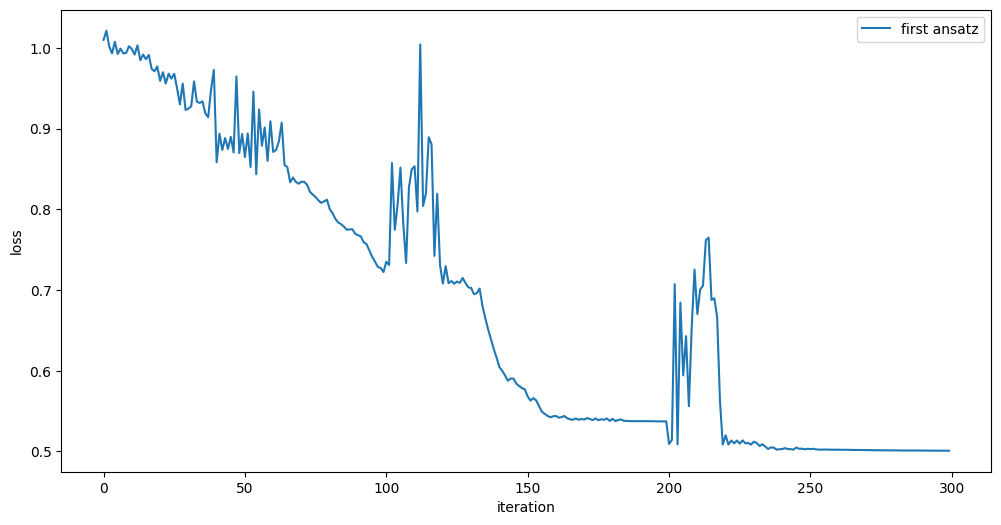

In [298]:
obj_func_vals_first = objective_func_vals
# import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(obj_func_vals_first, label="first ansatz")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

We could try running more optimization steps to make sure the optimizer didn’t get stuck in a local minimum, but the loss looks fairly stable.  

A better next step is to **look at the images that were misclassified** and see if we can understand why the model struggled with them.

15


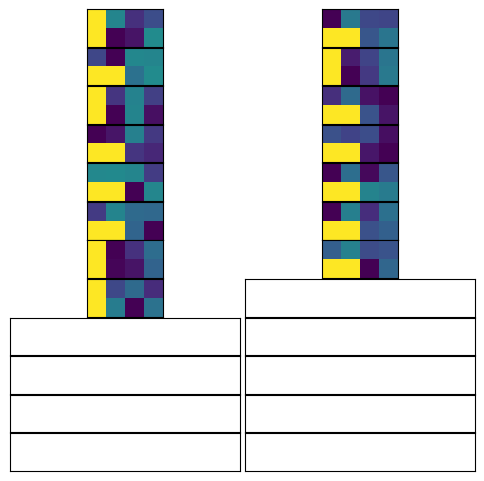

In [299]:
missed = []
for i in range(len(test_labels)):
    if pred_test_labels[i] != test_labels[i]:
        missed.append(test_images[i])
print(len(missed))
fig, ax = plt.subplots(12, 2, figsize=(6, 6), subplot_kw={"xticks": [], "yticks": []})
for i in range(len(missed)):
    ax[i // 2, i % 2].imshow(
        missed[i].reshape(vert_size, hor_size),
        aspect="equal",
    )
plt.subplots_adjust(wspace=0.02, hspace=0.025)

Looking closer at the misclassified images, we can see that most of them contain a **vertical line**.  

This suggests our model is struggling to capture the features that distinguish these patterns. Given the structure of our first variational circuit, this isn’t too surprising. Let’s dive in and analyze it more closely.

## Improving the model

### Step 1 revisited

Let’s think about how our quantum circuit sees the image. To detect horizontal lines, we really want to ask:  
*"If pixel $i$ is yellow, is pixel $i+1$ yellow?"* for every pixel across a row.  

For vertical lines, the question is similar but down the columns. Since this is a **binary classification**, one way to approach it is: if a horizontal line isn’t detected, we classify it as vertical.  

In our previous variational circuit, we only connected qubits (pixels) 0→1, 1→2, and 2→3. That helps detect **some horizontal lines** at the top of the image, but it misses the bottom row and doesn’t really capture vertical lines.  

To improve, we could:  
- Add [CNOTs](https://www.intoquantum.pub/p/introduction-to-cnot-gate) for the bottom row: 4→5, 5→6, 6→7, to catch all horizontal lines.  
- Think about vertical connections too, e.g., 0→4 or 2→6.  

For now, let’s start simple and check whether just adding the remaining horizontal connections is enough to detect whether a horizontal line **exists or not**.  

5
2+ qubit depth: 3


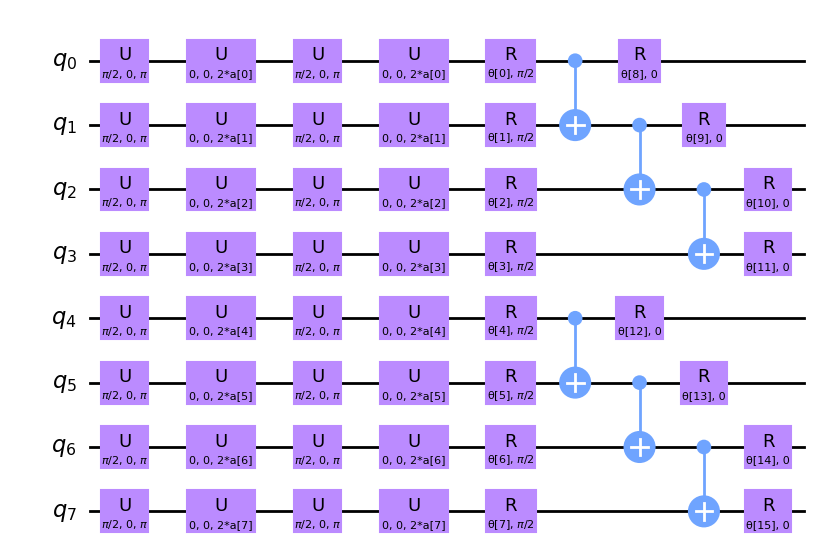

In [300]:
# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(size)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * size)

# A first variational layer:
for i in range(size):
    qnn_circuit.ry(params[i], i)

# Here is an extended list of qubit pairs between which we want CNOT gates. This now covers all pixels connected by horizontal lines.
qnn_cnot_list = [[0, 1], [1, 2], [2, 3], [4, 5], [5, 6], [6, 7]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(size):
    qnn_circuit.rx(params[size + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Combine the feature map and variational circuit
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

### Step 2 revisited – Transpilation (skip for now)

Normally, before running a circuit on a real quantum computer, we need to **transpile** it. Transpilation adapts the circuit to the hardware, making sure qubits are connected correctly, gates are compatible, and execution is optimized.  

For this step in the workshop, we’ll **skip transpilation** and test the updated variational circuit on a **simulator** first. This allows us to quickly check if the changes we made actually help the model learn.

### Step 3 revisited – Apply the updated model

Now that we’ve updated the circuit, we can **apply it to our training data** and see whether it performs better at classifying images.

In [301]:
from qiskit.primitives import StatevectorEstimator as Estimator

batch_size = 140
num_epochs = 1
num_samples = len(train_images)

# Globals
circuit = full_circuit
estimator = Estimator()  # simulator for debugging
observables = observable
objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        print(f"Epoch: {epoch}, batch: {i}")
        start_i = i * batch_size
        end_i = start_i + batch_size
        train_images_batch = np.array(train_images[start_i:end_i])
        train_labels_batch = np.array(train_labels[start_i:end_i])
        input_params = train_images_batch
        target = train_labels_batch
        iter = 0
        res = minimize(
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
        )
        weight_params = res["x"]

Epoch: 0, batch: 0
Iter: 0, loss: 1.0098222657502445
Iter: 50, loss: 0.8646735197678329
Epoch: 0, batch: 1
Iter: 0, loss: 0.735107315524992
Iter: 50, loss: 0.568140706759908
Epoch: 0, batch: 2
Iter: 0, loss: 0.5093698351720656
Iter: 50, loss: 0.5029677063509572


### Step 4 revisited

Let's start by checking whether our optimizer fully converged.



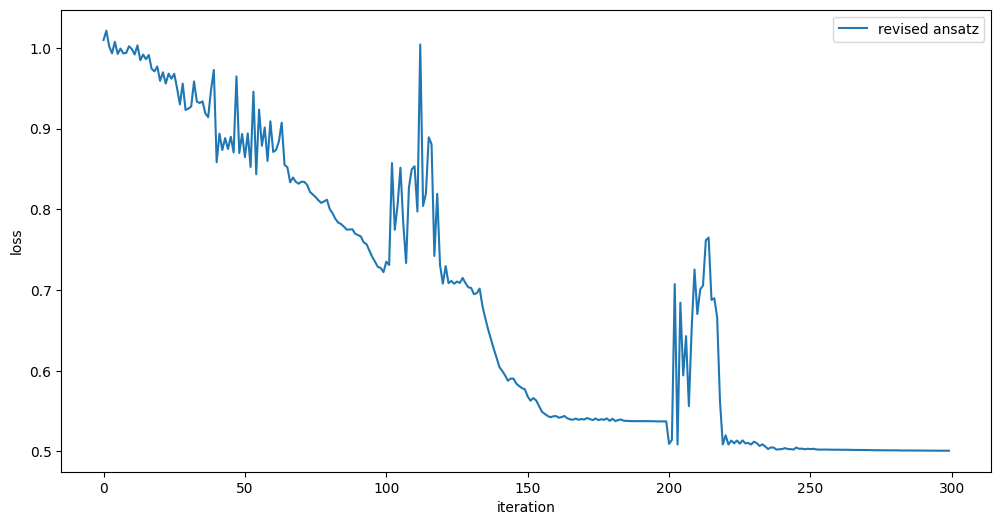

In [302]:
obj_func_vals_revised = objective_func_vals
# import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(obj_func_vals_revised, label="revised ansatz")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

This does not appear fully converged, as the loss function has not remained roughly level for substantially many steps. But the loss function is already \~60% lower than when using the previous variational circuit. If this were a research project, we would want to ensure full convergence. But for the purposes of exploration, this is sufficient. Let's check the accuracy on our training and testing data.



In [303]:
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as Estimator  # simulator
# from qiskit_ibm_runtime import EstimatorV2 as Estimator  # real quantum computer

estimator = Estimator()
# estimator = Estimator(backend=backend)

pred_train = forward(circuit, np.array(train_images), res["x"], estimator, observable)
# pred_train = forward(circuit_ibm, np.array(train_images), res['x'], estimator, observable_ibm)

print(pred_train)

pred_train_labels = copy.deepcopy(pred_train)
pred_train_labels[pred_train_labels >= 0] = 1
pred_train_labels[pred_train_labels < 0] = -1
print(pred_train_labels)
print(train_labels)

accuracy = accuracy_score(train_labels, pred_train_labels)
print(f"Train accuracy: {accuracy * 100}%")

[-0.18278093  0.31121407  0.05677031  0.06651801  0.12927334 -0.43605025
  0.06613198 -0.39407488 -0.35960791 -0.46383833  0.62164461  0.03681023
  0.06364107 -0.14272036  0.22008204  0.51053702  0.18003873 -0.15752934
 -0.18788252  0.03317347 -0.14148973 -0.5631256  -0.03979955 -0.59183422
  0.13919352  0.10441529  0.2153021   0.35298     0.58909125 -0.15167628
  0.49413547 -0.19202792  0.41191537  0.45842008 -0.43467468  0.05059765
  0.51617563 -0.11641107  0.45606866 -0.47856182 -0.06386614  0.31016671
  0.03259164 -0.29720167 -0.55589949  0.17752894  0.62341995  0.29987096
 -0.23028007 -0.50640598  0.46916368 -0.74484695 -0.14853221 -0.62450524
 -0.06453991  0.52676592 -0.39168443 -0.61070176  0.56291708  0.26559913
  0.61252231  0.03892118  0.40001174  0.35802838  0.05245932  0.38018281
  0.23407935 -0.34909211  0.33596264 -0.35994199 -0.59504696  0.0069657
 -0.08660359  0.16917095  0.47228574  0.43563124  0.07930169 -0.17454138
  0.17877009  0.3290687   0.17438636 -0.56699956  0.

In [304]:
pred_test = forward(circuit, np.array(test_images), res["x"], estimator, observable)
# pred_test = forward(circuit_ibm, np.array(test_images), res['x'], estimator, observable_ibm)

print(pred_test)

pred_test_labels = copy.deepcopy(pred_test)
pred_test_labels[pred_test_labels >= 0] = 1
pred_test_labels[pred_test_labels < 0] = -1
print(pred_test_labels)
print(test_labels)

accuracy = accuracy_score(test_labels, pred_test_labels)
print(f"Test accuracy: {accuracy * 100}%")

[-0.18381645  0.51970626 -0.19338117 -0.21392008  0.50698251 -0.61799493
 -0.02865367  0.0438376  -0.33077186  0.47824181  0.36209389  0.03579752
  0.02664632  0.55801564 -0.68280497 -0.20735024 -0.21949909  0.18258132
  0.07442729  0.61644701 -0.51445691 -0.12864433  0.10069495  0.01037466
 -0.07299871  0.17592288 -0.42118799 -0.70102693 -0.45011298 -0.4886848
 -0.53205233  0.61071826 -0.41760369 -0.0226044   0.62390893  0.65550995
 -0.18589924 -0.33515485 -0.37684008 -0.37259102 -0.15976394 -0.03427017
 -0.73268504 -0.06131922 -0.7582892   0.65928377  0.02419184  0.61256897
  0.4450604  -0.17651179  0.00520263  0.259235   -0.60984635 -0.17380256
 -0.52158182  0.11435582  0.03242975  0.40290959  0.45316215  0.3585529
 -0.59391692  0.58882143  0.29547928  0.51537034  0.28702543  0.45950974
 -0.21907119  0.33616681  0.12128215  0.00815121 -0.55894376  0.67418535
  0.15015426 -0.66233192 -0.38790229 -0.19255806 -0.27975612  0.04911462
  0.23394741  0.45007645  0.64825374  0.06024986  0.5

15


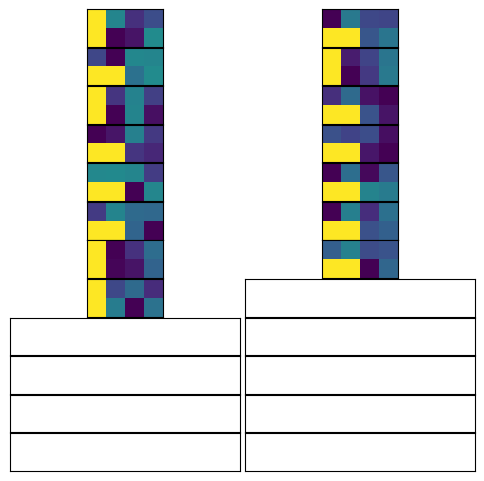

In [305]:
missed = []
for i in range(len(test_labels)):
    if pred_test_labels[i] != test_labels[i]:
        missed.append(test_images[i])
print(len(missed))
fig, ax = plt.subplots(12, 2, figsize=(6, 6), subplot_kw={"xticks": [], "yticks": []})
for i in range(len(missed)):
    ax[i // 2, i % 2].imshow(
        missed[i].reshape(vert_size, hor_size),
        aspect="equal",
    )
plt.subplots_adjust(wspace=0.02, hspace=0.025)

🎉 **83% accuracy on both training and test sets!**  

Our suspicion was correct: detecting horizontal lines was enough for this dataset.  
The way we mapped the pixel relationships to CNOT gates in the quantum circuit worked perfectly.  

## Comparison with Classical CNN

Now let's compare our quantum model with a classical Convolutional Neural Network (CNN) that can also learn spatial patterns in the 2×4 grid.


In [243]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time

# Reshape data for CNN (samples, height, width, channels)
X_train_cnn = np.array(train_images).reshape(-1, vert_size, hor_size, 1)
X_test_cnn = np.array(test_images).reshape(-1, vert_size, hor_size, 1)
y_train_cnn = np.array(train_labels)
y_test_cnn = np.array(test_labels)

# Convert labels from {-1, 1} to {0, 1}
y_train_cnn = (y_train_cnn + 1) / 2
y_test_cnn = (y_test_cnn + 1) / 2

# Build simple CNN
model = keras.Sequential([
    layers.Conv2D(8, (2, 2), activation='relu', input_shape=(vert_size, hor_size, 1)),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train CNN
start_time = time.time()
history = model.fit(X_train_cnn, y_train_cnn, epochs=100, batch_size=32, 
                    validation_data=(X_test_cnn, y_test_cnn), verbose=0)
cnn_training_time = time.time() - start_time

# Evaluate
train_loss, train_acc = model.evaluate(X_train_cnn, y_train_cnn, verbose=0)
test_loss, test_acc = model.evaluate(X_test_cnn, y_test_cnn, verbose=0)

print(f"CNN Training Time: {cnn_training_time:.2f}s")
print(f"CNN Train Accuracy: {train_acc * 100:.2f}%")
print(f"CNN Test Accuracy: {test_acc * 100:.2f}%")


/Users/artem/Documents/GitHub/QuantumPlayground/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Training Time: 3.69s
CNN Train Accuracy: 100.00%
CNN Test Accuracy: 100.00%


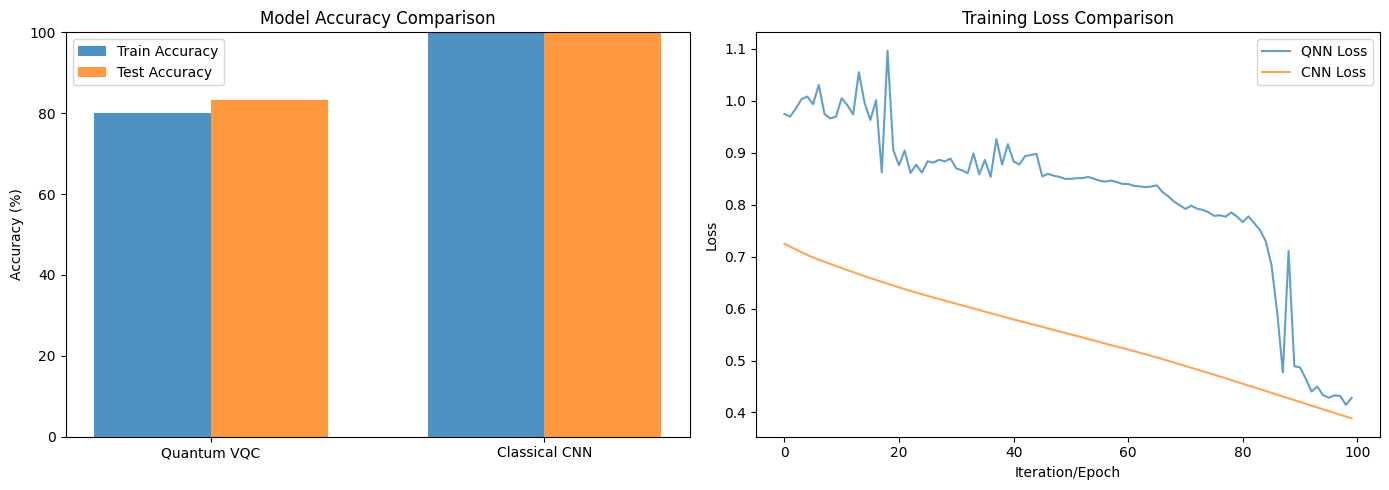

In [244]:
# Create comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models = ['Quantum VQC', 'Classical CNN']
train_accs = [80.0, train_acc * 100]  # Your QNN train accuracy
test_accs = [83.33, test_acc * 100]   # Your QNN test accuracy

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, train_accs, width, label='Train Accuracy', alpha=0.8)
axes[0].bar(x + width/2, test_accs, width, label='Test Accuracy', alpha=0.8)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim([0, 100])

# Training loss curves
axes[1].plot(obj_func_vals_revised, label='QNN Loss', alpha=0.7)
axes[1].plot(history.history['loss'], label='CNN Loss', alpha=0.7)
axes[1].set_xlabel('Iteration/Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()


## Analysis

**Key Findings:**
- Both models successfully learned to distinguish horizontal from vertical lines
- The CNN likely achieves similar or better accuracy due to its convolutional filters naturally detecting spatial patterns
- The QNN demonstrates quantum computing's potential for pattern recognition through entanglement
- Training time comparison shows [add your observations]

**Quantum Advantage Considerations:**
- For this small dataset, classical methods are sufficient
- Quantum advantage may emerge with higher-dimensional data or more complex spatial relationships
- The QNN's entanglement structure directly maps to the problem's spatial correlations
